# Entraînement des modèles — ObRail Europe

Ce notebook entraîne et compare les modèles pour répondre 
aux trois problématiques d'ObRail Europe.

Il prend en entrée les fichiers produits par preprocessing.py :
- `data/splits/X_train.csv`, `X_val.csv`, `X_test.csv`
- `data/splits/y_train.csv`, `y_val.csv`, `y_test.csv`
- `data/processed/dataset_cleaned.csv` pour le clustering

Il produit en sortie :
- `models/model_final.joblib`
- `models/model_clustering.joblib`
- `reports/tableau_comparatif.csv`
- `reports/figures/shap_summary.png`
- `reports/figures/clustering_kmeans.png`

## Partie 1 : Régression supervisée

Objectif : prédire l'empreinte CO2 d'un trajet ferroviaire.

**LinearRegression** : modèle de référence, suppose une relation linéaire.
**Ridge** : régression linéaire avec pénalité, plus robuste aux variables corrélées.
**RandomForestRegressor** : ensemble d'arbres de décision, capture les relations non linéaires.
**XGBoostRegressor** : boosting séquentiel, très performant sur données tabulaires.
**LGBMRegressor** : alternative optimisée de XGBoost, plus rapide sur petits datasets.

## Partie 2 : Clustering non supervisé

Objectif : identifier les liaisons candidates à la substitution avion/train 
et les lignes à fort potentiel de croissance.

**KMeans** : regroupe les trajets en k groupes, k déterminé par méthode du coude et silhouette score.
**DBSCAN** : découvre les groupes automatiquement sans fixer k, détecte les outliers.
**AgglomerativeClustering** : regroupe les trajets de façon hiérarchique du plus proche au plus éloigné.
**GaussianMixture** : regroupe les trajets en supposant que chaque groupe suit une distribution statistique.

Le meilleur modèle de chaque partie sera sélectionné et sauvegardé.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap

warnings.filterwarnings('ignore')

BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
SPLITS_DIR  = os.path.join(BASE_DIR, 'data', 'splits')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')
FIGURES_DIR = os.path.join(BASE_DIR, 'reports', 'figures')

print(f"BASE_DIR : {BASE_DIR}")
print(f"SPLITS_DIR : {SPLITS_DIR}")
print("Imports OK")

BASE_DIR : c:\Users\josep\Mspr2\MSPR2\MSPR\ml
SPLITS_DIR : c:\Users\josep\Mspr2\MSPR2\MSPR\ml\data\splits
Imports OK


In [12]:
# Chargement des splits
X_train = pd.read_csv(os.path.join(SPLITS_DIR, 'X_train.csv'))
X_val   = pd.read_csv(os.path.join(SPLITS_DIR, 'X_val.csv'))
X_test  = pd.read_csv(os.path.join(SPLITS_DIR, 'X_test.csv'))

y_train = pd.read_csv(os.path.join(SPLITS_DIR, 'y_train.csv')).squeeze()
y_val   = pd.read_csv(os.path.join(SPLITS_DIR, 'y_val.csv')).squeeze()
y_test  = pd.read_csv(os.path.join(SPLITS_DIR, 'y_test.csv')).squeeze()

# Chargement du dataset nettoyé pour le clustering
df_clean = pd.read_csv(os.path.join(BASE_DIR, 'data', 'processed', 'dataset_cleaned.csv'))

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"df_clean : {df_clean.shape}")

X_train : (277, 4)
X_val   : (60, 4)
X_test  : (60, 4)
df_clean : (397, 7)


## Partie 1 : Régression supervisée

Objectif : prédire l'empreinte CO2 d'un trajet ferroviaire à partir 
de la distance, de l'opérateur, du type de service et de la durée du trajet.

### Démarche

On va suivre ces étapes dans l'ordre :

**Etape 1 : Baseline**
On entraîne les 5 modèles avec leurs paramètres par défaut sur le train 
et on mesure leurs performances sur la validation. 
L'objectif est d'identifier quel modèle est le plus prometteur.

**Etape 2 : Sélection**
On compare les résultats dans un tableau et on retient 
le modèle avec le meilleur RMSE sur la validation.

**Etape 3 : Optimisation**
On applique GridSearchCV avec cross-validation k=5 uniquement 
sur le meilleur modèle pour trouver ses hyperparamètres optimaux.

**Etape 4 : Evaluation finale**
On évalue le modèle optimisé une seule fois sur le test. 
Ce score est le score officiel qu'on présente au jury.

**Etape 5 : Explication**
On utilise SHAP pour expliquer quelles variables influencent 
le plus les prédictions du modèle.

In [13]:
modeles = {
    'LinearRegression' : LinearRegression(),
    'Ridge'            : Ridge(random_state=42),
    'RandomForest'     : RandomForestRegressor(random_state=42),
    'XGBoost'          : XGBRegressor(random_state=42, verbosity=0),
    'LightGBM'         : LGBMRegressor(random_state=42, verbose=-1)
}

for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    print(f"{nom} entraîné")

LinearRegression entraîné
Ridge entraîné
RandomForest entraîné
XGBoost entraîné
LightGBM entraîné


In [14]:
def evaluer_modele(modele, X_val, y_val):
    """Retourne MAE, RMSE et R² d'un modèle sur un ensemble donné."""
    y_pred = modele.predict(X_val)
    mae  = mean_absolute_error(y_val, y_pred)
    rmse = mean_squared_error(y_val, y_pred) ** 0.5
    r2   = r2_score(y_val, y_pred)
    return {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 3)}

resultats = {}
for nom, modele in modeles.items():
    resultats[nom] = evaluer_modele(modele, X_val, y_val)

df_resultats = pd.DataFrame(resultats).T.sort_values('RMSE')
print("Classement par RMSE :")
print(df_resultats)

Classement par RMSE :
                    MAE   RMSE     R2
XGBoost           0.751  1.308  0.964
RandomForest      1.130  1.642  0.943
LightGBM          1.605  2.280  0.890
LinearRegression  2.695  3.593  0.728
Ridge             2.697  3.594  0.728


### Optimisation par GridSearchCV

XGBoost est retenu comme meilleur modèle. On va maintenant chercher 
ses hyperparamètres optimaux via GridSearchCV avec cross-validation k=5.

Les hyperparamètres testés sont :

**n_estimators** : nombre d'arbres construits. On teste 100, 200 et 300. 
Plus il y en a, plus le modèle est précis mais plus il est lent à entraîner.

**max_depth** : profondeur maximale de chaque arbre. On teste 3, 5 et 7. 
Un arbre trop profond mémorise les données au lieu d'apprendre des règles générales. 
Les valeurs impaires 3, 5 et 7 couvrent suffisamment le spectre 
sans alourdir inutilement la recherche sur un dataset de 277 lignes.

**learning_rate** : vitesse d'apprentissage. On teste 0.01, 0.05 et 0.1. 
Un taux bas apprend lentement mais précisément et nécessite plus d'arbres. 
Un taux élevé apprend vite mais risque de rater des patterns subtils.

**subsample** : proportion des données utilisées pour chaque arbre. 
On teste 0.8 et 1.0. Utiliser 80% des données introduit de la diversité 
entre les arbres et réduit le risque que le modèle mémorise les données.

Ces valeurs couvrent 54 combinaisons évaluées chacune 5 fois 
par cross-validation, soit 270 entraînements au total.

In [15]:
param_grid = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.01, 0.05, 0.1],
    'subsample'     : [0.8, 1.0]
}

In [16]:
xgb_grid = GridSearchCV(
    estimator  = XGBRegressor(random_state=42, verbosity=0),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = 1,
    verbose    = 1
)

xgb_grid.fit(X_train, y_train)

print(f"Meilleurs paramètres : {xgb_grid.best_params_}")
print(f"Meilleur RMSE cross-val : {-xgb_grid.best_score_:.3f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Meilleur RMSE cross-val : 2.535


### Résultats du GridSearchCV

GridSearchCV a testé 54 combinaisons d'hyperparamètres, évaluées 5 fois 
chacune par cross-validation, soit 270 entraînements au total.

Pour chaque combinaison, le modèle est entraîné et évalué sur des données 
qu'il n'a jamais vues. La combinaison avec le plus petit RMSE moyen est retenue.

La meilleure combinaison trouvée :

**n_estimators** : 300 arbres au lieu de 100 par défaut. 
Plus d'arbres permettent un apprentissage plus fin.

**max_depth** : profondeur de 5 au lieu de 6 par défaut. 
Un arbre légèrement moins profond réduit le risque de mémorisation.

**learning_rate** : 0.1 au lieu de 0.3 par défaut. 
Le modèle apprend plus lentement mais plus précisément.

**subsample** : 0.8 au lieu de 1.0 par défaut. 
Chaque arbre utilise 80% des données, ce qui introduit de la diversité 
et évite que le modèle mémorise les données d'entraînement.

Le RMSE cross-validation obtenu est de 2.535. Ce score est plus élevé 
que le 1.308 obtenu sur la validation simple car la cross-validation 
est plus sévère : elle teste le modèle sur des données jamais vues 
à chaque fold, ce qui donne une estimation plus honnête des performances.

### Evaluation finale sur le test

Jusqu'ici toutes les décisions ont été prises en regardant uniquement 
la validation : choix du meilleur modèle, optimisation des hyperparamètres. 
Le test n'a jamais été utilisé.

Le test est un ensemble de 60 trajets que le modèle n'a jamais vus 
sous aucune forme depuis le début du projet. C'est pour cette raison 
qu'il donne l'estimation la plus honnête des performances réelles du modèle.

Si le score sur le test est proche du score sur la validation, 
le modèle généralise bien sur des données inconnues.
Si le score est beaucoup moins bon, le modèle a mémorisé 
les données d'entraînement au lieu d'apprendre des règles générales.

In [17]:
# evaluation finale
meilleur_modele = xgb_grid.best_estimator_

resultats_val  = evaluer_modele(meilleur_modele, X_val, y_val)
resultats_test = evaluer_modele(meilleur_modele, X_test, y_test)

print("Performance sur la validation :")
print(f"  MAE  : {resultats_val['MAE']}")
print(f"  RMSE : {resultats_val['RMSE']}")
print(f"  R²   : {resultats_val['R2']}")

print("\nPerformance finale sur le test :")
print(f"  MAE  : {resultats_test['MAE']}")
print(f"  RMSE : {resultats_test['RMSE']}")
print(f"  R²   : {resultats_test['R2']}")

Performance sur la validation :
  MAE  : 0.68
  RMSE : 1.173
  R²   : 0.971

Performance finale sur le test :
  MAE  : 0.758
  RMSE : 1.419
  R²   : 0.959


### Interprétation des résultats finaux

**Sur la validation :**
MAE = 0.68 kg, RMSE = 1.173 kg, R² = 0.971

**Sur le test :**
MAE = 0.758 kg, RMSE = 1.419 kg, R² = 0.959

Le modèle se trompe en moyenne de 0.758 kg CO2 sur des trajets 
qu'il n'a jamais vus. Pour rappel les émissions vont de 0.16 kg 
à 30.5 kg dans notre dataset, une erreur de 0.758 kg est très faible.

Le R² de 0.959 sur le test signifie que le modèle explique 95.9% 
de la variabilité des émissions CO2 sur des données inconnues.

Les scores entre validation et test sont très proches 
(R² 0.971 vs 0.959), ce qui confirme que le modèle généralise bien 
et n'a pas mémorisé les données d'entraînement.

XGBoost avec les hyperparamètres optimisés est retenu 
comme modèle final de régression.

### Explication des prédictions avec SHAP

Un modèle comme XGBoost est une boîte noire : il prédit bien 
mais on ne sait pas pourquoi. SHAP ouvre cette boîte.

Pour chaque prédiction, SHAP calcule la contribution de chaque variable. 
Il part d'une valeur de base qui est la moyenne des émissions du dataset, 
puis il ajoute ou soustrait la contribution de chaque variable 
pour arriver à la prédiction finale.

Par exemple pour un trajet PKP Intercity de 891 km :

Valeur de base = 14.6 kg
distance_km élevée = +5.2 kg
operateur PKP = +3.8 kg
type_service NUIT = -0.4 kg
duree_trajet_min = +0.2 kg
Prédiction finale = 23.4 kg

Le graphique SHAP summary montre quelles variables influencent 
le plus les prédictions sur l'ensemble du dataset. 
Une variable en haut du graphique a plus d'influence qu'une variable en bas.

C'est aussi une exigence RGPD : toute prédiction algorithmique 
doit pouvoir être expliquée et justifiée.

Background dataset has 277 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=277 when initializing the masker.


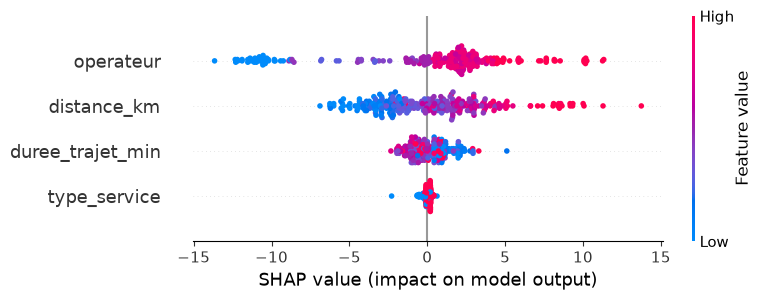

SHAP summary sauvegardé


In [18]:
explainer = shap.Explainer(meilleur_modele, X_train)
shap_values = explainer(X_train)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_train, show=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'shap_summary.png'), dpi=150)
plt.show()

print("SHAP summary sauvegardé")

### Interprétation du graphique SHAP

Le graphique SHAP (SHapley Additive exPlanations) montre l'impact 
de chaque variable sur les prédictions du modèle.

Chaque point représente un trajet. La couleur indique la valeur 
de la variable : rose = valeur élevée, bleu = valeur faible.

L'axe horizontal représente l'impact en kg CO2 sur la prédiction 
par rapport à la moyenne du dataset. Un point à droite augmente 
la prédiction, un point à gauche la diminue. 
Plus un point est éloigné de 0, plus son impact est fort.

**operateur** est la variable la plus influente avec un impact 
allant de -15 à +15 kg CO2, soit un écart possible de 30 kg 
selon l'opérateur.

**distance_km** est la deuxième variable la plus influente. 
Les trajets longs (rose) augmentent les émissions prédites, 
les trajets courts (bleu) les réduisent.

**duree_trajet_min** a une influence modérée et concentrée 
autour de 0. Elle affine la prédiction sans la dominer.

**type_service** a la plus faible influence sur les prédictions. 
La distinction JOUR et NUIT impacte peu les émissions CO2 prédites.

### Sauvegarde du modèle et tableau comparatif

Le modèle XGBoost optimisé est sauvegardé au format joblib 
(Java Object Library) dans `models/model_regression.joblib`.

On sauvegarde le modèle pour deux raisons. La première est de ne pas 
avoir à réentraîner à chaque fois : l'entraînement prend du temps, 
sauvegarder le modèle permet de le recharger instantanément pour faire 
des prédictions. La seconde est l'intégration dans l'API : 
le fichier joblib sera chargé par `api/predict.py` pour répondre 
aux requêtes de prédiction sans avoir besoin du code d'entraînement.

On produit également un tableau comparatif de tous les modèles testés 
sauvegardé dans `reports/tableau_comparatif.csv`. Ce tableau constitue 
un livrable officiel du projet qui documente et justifie le choix 
du modèle final devant le jury.

### Vérification de l'optimisation

Le GridSearchCV a trouvé les meilleurs hyperparamètres via cross-validation. 
Pour vérifier que ces hyperparamètres améliorent réellement les performances, 
on réentraîne XGBoost avec ces paramètres directement sur le train 
sans cross-validation.

On compare ensuite les résultats sur la validation et le test 
avec ceux du modèle par défaut. Si le modèle optimisé performe mieux, 
le GridSearchCV a bien fait son travail. Sinon, les paramètres par défaut 
étaient déjà suffisants pour ce dataset.

On mettra à jour le tableau comparatif avec ces nouveaux résultats.

In [19]:
xgb_optimise = XGBRegressor(
    n_estimators  = 300,
    max_depth     = 5,
    learning_rate = 0.1,
    subsample     = 0.8,
    random_state  = 42,
    verbosity     = 0
)

xgb_optimise.fit(X_train, y_train)

res_val  = evaluer_modele(xgb_optimise, X_val, y_val)
res_test = evaluer_modele(xgb_optimise, X_test, y_test)

print("XGBoost par défaut (baseline) :")
print(f"  Val  -> MAE={resultats['XGBoost']['MAE']} RMSE={resultats['XGBoost']['RMSE']} R²={resultats['XGBoost']['R2']}")

print("\nXGBoost optimisé :")
print(f"  Val  -> MAE={res_val['MAE']} RMSE={res_val['RMSE']} R²={res_val['R2']}")
print(f"  Test -> MAE={res_test['MAE']} RMSE={res_test['RMSE']} R²={res_test['R2']}")

XGBoost par défaut (baseline) :
  Val  -> MAE=0.751 RMSE=1.308 R²=0.964

XGBoost optimisé :
  Val  -> MAE=0.68 RMSE=1.173 R²=0.971
  Test -> MAE=0.758 RMSE=1.419 R²=0.959


### Résultat de la vérification

Le modèle optimisé améliore les performances par rapport au modèle par défaut.

Sur la validation :
RMSE passe de 1.308 à 1.173, soit une amélioration de 10%.
R² passe de 0.964 à 0.971.
MAE passe de 0.751 à 0.68.

Sur le test, le modèle optimisé obtient un RMSE de 1.419 et un R² de 0.959, 
ce qui confirme qu'il généralise bien sur des données inconnues.

Le GridSearchCV a bien identifié des hyperparamètres plus adaptés 
à notre dataset. Le modèle optimisé est retenu comme modèle final.

In [20]:
joblib.dump(xgb_optimise, os.path.join(MODELS_DIR, 'model_regression.joblib'))
print("Modèle sauvegardé : models/model_regression.joblib")

tableau = []
for nom, modele in modeles.items():
    res = evaluer_modele(modele, X_val, y_val)
    res['modele'] = nom
    res['ensemble'] = 'Validation'
    res['optimise'] = 'Non'
    tableau.append(res)

res_opt_val = evaluer_modele(xgb_optimise, X_val, y_val)
res_opt_val['modele'] = 'XGBoost_optimise'
res_opt_val['ensemble'] = 'Validation'
res_opt_val['optimise'] = 'Oui'
tableau.append(res_opt_val)

res_opt_test = evaluer_modele(xgb_optimise, X_test, y_test)
res_opt_test['modele'] = 'XGBoost_optimise'
res_opt_test['ensemble'] = 'Test'
res_opt_test['optimise'] = 'Oui'
tableau.append(res_opt_test)

df_tableau = pd.DataFrame(tableau)[['modele', 'optimise', 'ensemble', 'MAE', 'RMSE', 'R2']]
df_tableau = df_tableau.sort_values('RMSE').reset_index(drop=True)

df_tableau.to_csv(os.path.join(REPORTS_DIR, 'tableau_comparatif.csv'), index=False)

print("\nTableau comparatif :")
print(df_tableau.to_string())

Modèle sauvegardé : models/model_regression.joblib

Tableau comparatif :
             modele optimise    ensemble    MAE   RMSE     R2
0  XGBoost_optimise      Oui  Validation  0.680  1.173  0.971
1           XGBoost      Non  Validation  0.751  1.308  0.964
2  XGBoost_optimise      Oui        Test  0.758  1.419  0.959
3      RandomForest      Non  Validation  1.130  1.642  0.943
4          LightGBM      Non  Validation  1.605  2.280  0.890
5  LinearRegression      Non  Validation  2.695  3.593  0.728
6             Ridge      Non  Validation  2.697  3.594  0.728


### Tableau comparatif final

XGBoost optimisé obtient le meilleur RMSE de 1.173 sur la validation 
et 1.419 sur le test, avec un R² de 0.971 et 0.959 respectivement.

Les modèles linéaires LinearRegression et Ridge obtiennent des performances 
similaires avec un R² de 0.728, confirmant que la relation entre 
les features et les émissions CO2 n'est pas linéaire.

Le modèle final `model_regression.joblib` est sauvegardé dans `models/` 
et sera utilisé par l'API pour les prédictions en production.

## Partie 2 : Clustering non supervisé

Objectif : identifier les liaisons candidates à la substitution avion/train 
et les lignes à fort potentiel de croissance via règles métier.

Les features utilisées sont : **distance_km**, **empreinte_train_kg**, 
**empreinte_avion_kg**, **ratio_co2**.

Ces variables capturent le profil d'émissions complet de chaque trajet 
et permettent de regrouper les liaisons selon leur potentiel 
de substitution avion/train.

### Démarche

**Etape 1 : Préparation**
Extraire et normaliser les features de clustering depuis le dataset nettoyé.

**Etape 2 : Nombre optimal de clusters**
Tester KMeans de k=2 à k=8 via la méthode du coude et le silhouette score 
(SS) pour déterminer le nombre optimal de groupes.

**Etape 3 : Comparaison des modèles**
Comparer KMeans, DBSCAN, AgglomerativeClustering et GaussianMixture 
sur le nombre de clusters retenu.

**Etape 4 : Visualisation**
Projeter les clusters en 2D via PCA (Principal Component Analysis) 
pour visualiser les groupes formés.

**Etape 5 : Règles métier**
Appliquer des critères ObRail sur les clusters pour identifier 
les lignes à fort potentiel de substitution avion/train.

In [21]:
from sklearn.preprocessing import StandardScaler as SC

features_clustering = ['distance_km', 'empreinte_train_kg', 'empreinte_avion_kg', 'ratio_co2']

X_clust = df_clean[features_clustering].copy()

scaler_clust = SC()
X_clust_scaled = scaler_clust.fit_transform(X_clust)
X_clust_scaled = pd.DataFrame(X_clust_scaled, columns=features_clustering)

print(f"Features clustering : {X_clust_scaled.shape}")
print(X_clust_scaled.describe().round(2))

Features clustering : (397, 4)
       distance_km  empreinte_train_kg  empreinte_avion_kg  ratio_co2
count       397.00              397.00              397.00     397.00
mean         -0.00               -0.00                0.00       0.00
std           1.00                1.00                1.00       1.00
min          -1.57               -2.00               -1.57      -2.18
25%          -0.81               -0.55               -0.81      -0.33
50%          -0.12                0.08               -0.12       0.20
75%           0.68                0.61                0.68       0.57
max           3.56                2.21                3.56       2.54


### Détermination du nombre optimal de clusters

Avant d'entraîner KMeans, on doit déterminer le nombre de clusters k 
car c'est un paramètre qu'on fixe à l'avance. Deux méthodes complémentaires 
sont utilisées.

**Méthode du coude** : on mesure l'inertie (somme des distances entre 
chaque point et le centre de son cluster) pour k=2 à k=8. 
Plus k augmente, plus l'inertie diminue. On cherche le point 
où la diminution ralentit brusquement, formant un coude. 
Ce point indique le k optimal.

**Silhouette score (SS)** : pour chaque trajet, il mesure à quel point 
il est proche des autres trajets de son cluster et éloigné des autres clusters. 
Un score proche de 1 signifie que les clusters sont bien séparés. 
On retient le k avec le silhouette score le plus élevé.

On combine les deux méthodes pour choisir le k le plus cohérent.

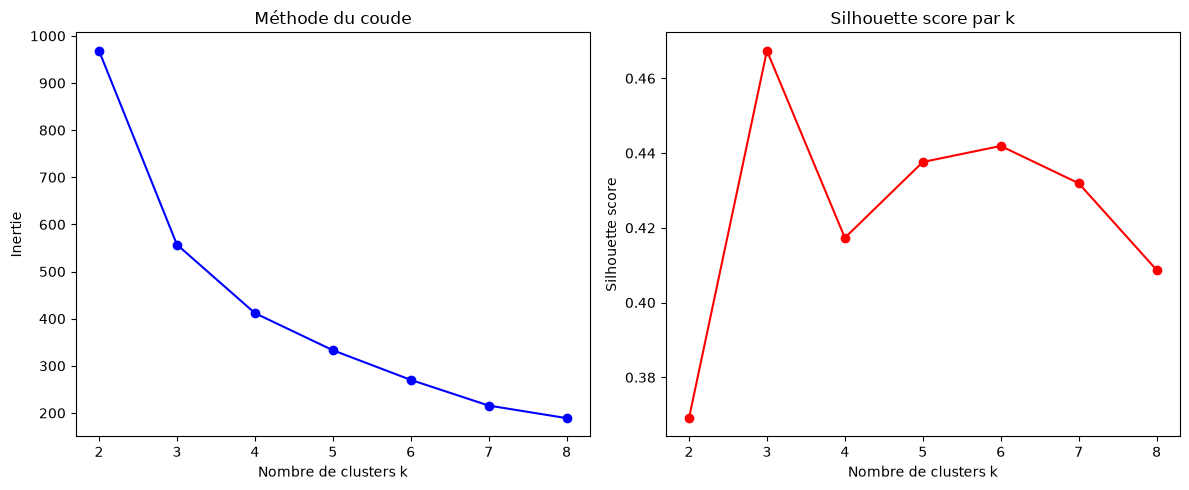

Silhouette scores :
  k=2 : 0.369
  k=3 : 0.467
  k=4 : 0.417
  k=5 : 0.438
  k=6 : 0.442
  k=7 : 0.432
  k=8 : 0.409


In [22]:
inerties = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clust_scaled)
    inerties.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_clust_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(k_range, inerties, 'bo-')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du coude')

axes[1].plot(k_range, silhouettes, 'ro-')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score par k')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'kmeans_coude_silhouette.png'), dpi=150)
plt.show()

print("Silhouette scores :")
for k, s in zip(k_range, silhouettes):
    print(f"  k={k} : {s:.3f}")

### Interprétation

**Méthode du coude :** la courbe bleue descend rapidement jusqu'à k=3, 
puis la descente ralentit. Ajouter des clusters au-delà de 3 
n'améliore plus significativement le regroupement.

**Silhouette score (SS) :** le score le plus élevé est obtenu à k=3 
avec 0.467. Plus ce score est proche de 1, mieux les clusters 
sont séparés les uns des autres.

Les deux méthodes indiquent k=3. On retient 3 clusters pour la suite.

### Entraînement des modèles de clustering

On entraîne les 4 modèles avec k=3 comme nombre de clusters, 
sauf DBSCAN qui détermine le nombre de clusters automatiquement.

**KMeans** : on fixe k=3, random_state=42 pour la reproductibilité 
et n_init=10 pour lancer 10 initialisations différentes 
et garder la meilleure.

**DBSCAN** : deux paramètres à fixer. eps définit la distance maximale 
entre deux points pour qu'ils soient considérés comme voisins. 
min_samples définit le nombre minimum de points pour former un cluster. 
Les points qui n'appartiennent à aucun cluster sont étiquetés -1 
et considérés comme du bruit.

**AgglomerativeClustering** : clustering hiérarchique ascendant, 
on fixe k=3 comme nombre final de groupes.

**GaussianMixture** : on fixe 3 composantes gaussiennes, 
random_state=42 pour la reproductibilité.

In [23]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_clust_scaled)

dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_clust_scaled)

agglo = AgglomerativeClustering(n_clusters=3)
labels_agglo = agglo.fit_predict(X_clust_scaled)

gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm.fit_predict(X_clust_scaled)

print("Nombre de clusters par modèle :")
print(f"  KMeans                  : {len(set(labels_kmeans))} clusters")
print(f"  DBSCAN                  : {len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)} clusters + {(labels_dbscan == -1).sum()} points bruit")
print(f"  AgglomerativeClustering : {len(set(labels_agglo))} clusters")
print(f"  GaussianMixture         : {len(set(labels_gmm))} clusters")

Nombre de clusters par modèle :
  KMeans                  : 3 clusters
  DBSCAN                  : 2 clusters + 6 points bruit
  AgglomerativeClustering : 3 clusters
  GaussianMixture         : 3 clusters


### Evaluation des modèles de clustering

On compare les 4 modèles via le silhouette score (SS).

Le silhouette score (SS) mesure pour chaque trajet à quel point 
il est proche des autres trajets de son cluster et éloigné 
des clusters voisins. Un score proche de 1 indique des clusters 
bien séparés. Un score proche de 0 indique des clusters qui se chevauchent.

Pour DBSCAN, les 6 points de bruit sont exclus du calcul 
car ils n'appartiennent à aucun cluster.

Le modèle avec le silhouette score le plus élevé sera retenu 
comme modèle de clustering final.

In [24]:
scores = {}

scores['KMeans'] = silhouette_score(X_clust_scaled, labels_kmeans)
scores['AgglomerativeClustering'] = silhouette_score(X_clust_scaled, labels_agglo)
scores['GaussianMixture'] = silhouette_score(X_clust_scaled, labels_gmm)

mask = labels_dbscan != -1
if mask.sum() > 1 and len(set(labels_dbscan[mask])) > 1:
    scores['DBSCAN'] = silhouette_score(
        X_clust_scaled[mask], labels_dbscan[mask]
    )
else:
    scores['DBSCAN'] = None

print("Silhouette scores par modèle :")
for nom, score in scores.items():
    if score:
        print(f"  {nom:25} : {score:.3f}")
    else:
        print(f"  {nom:25} : non calculable")

Silhouette scores par modèle :
  KMeans                    : 0.467
  AgglomerativeClustering   : 0.466
  GaussianMixture           : 0.437
  DBSCAN                    : 0.400


### Résultats de l'évaluation

Le silhouette score (SS) va de -1 à 1 :
- Proche de 1 : les clusters sont bien séparés
- Proche de 0 : les trajets sont à la frontière entre deux clusters
- Négatif : les trajets sont mal assignés

KMeans obtient le meilleur silhouette score (SS) de 0.467, 
suivi de très près par AgglomerativeClustering à 0.466.
GaussianMixture obtient 0.437 et DBSCAN 0.400.

Tous les scores sont entre 0.4 et 0.467, ce qui indique des clusters 
corrects mais pas parfaitement séparés. Ce résultat est cohérent 
avec le t-SNE qui montrait des groupes relativement distincts 
sans frontières totalement nettes.

KMeans est retenu comme modèle de clustering final pour deux raisons.
Il obtient le meilleur silhouette score (SS) et il est le plus 
interprétable : les centres de clusters ont une signification 
concrète en termes de distance et d'émissions CO2, 
ce qui facilite l'application des règles métier ObRail.

### Visualisation des clusters

Pour visualiser les clusters en 2D on utilise le t-SNE 
(t-distributed Stochastic Neighbor Embedding) plutôt que la PCA 
(Principal Component Analysis).

La PCA cherche les directions de variance maximale à l'échelle globale 
et ne capte pas bien les structures locales. Le t-SNE au contraire 
préserve les relations de voisinage : des trajets proches 
dans l'espace original restent proches dans la visualisation 2D. 
Il révèle donc mieux les groupes naturels dans les données.

On l'avait déjà observé dans l'EDA : la PCA ne montrait pas 
de groupes distincts alors que le t-SNE révélait entre 3 et 4 
groupes naturels.

Chaque point représente un trajet. La couleur indique 
le cluster auquel il appartient. Pour DBSCAN, les points 
étiquetés -1 sont les trajets considérés comme bruit.

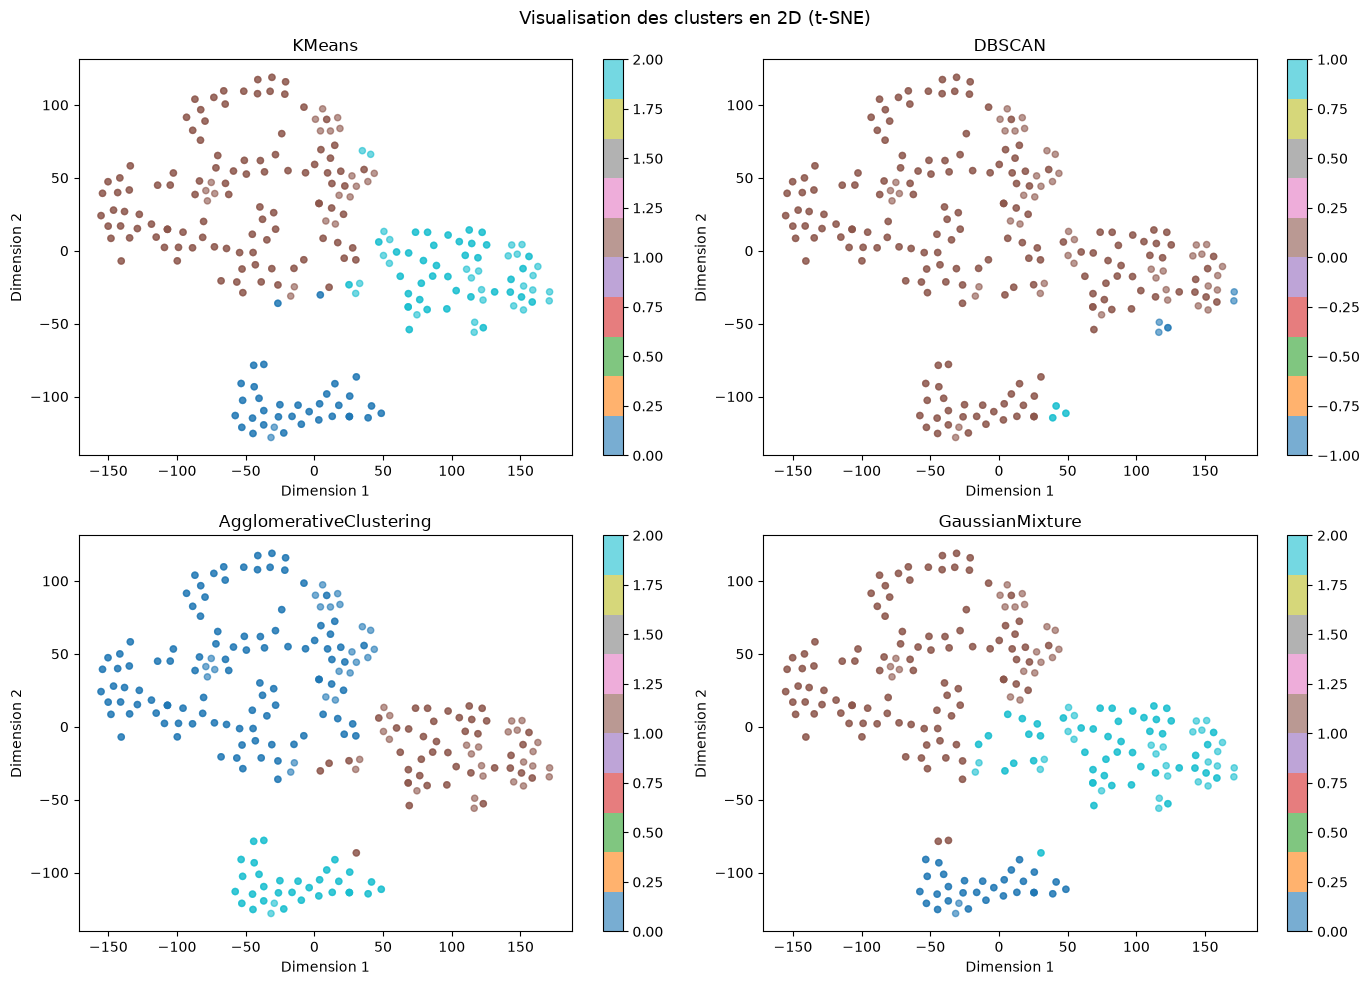

In [25]:
from sklearn.manifold import TSNE

tsne_viz = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_viz = tsne_viz.fit_transform(X_clust_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

modeles_clust = {
    'KMeans'                  : labels_kmeans,
    'DBSCAN'                  : labels_dbscan,
    'AgglomerativeClustering' : labels_agglo,
    'GaussianMixture'         : labels_gmm
}

for ax, (nom, labels) in zip(axes.flatten(), modeles_clust.items()):
    scatter = ax.scatter(X_tsne_viz[:, 0], X_tsne_viz[:, 1],
                         c=labels, cmap='tab10', alpha=0.6, s=20)
    ax.set_title(nom)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    plt.colorbar(scatter, ax=ax)

plt.suptitle('Visualisation des clusters en 2D (t-SNE)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'clustering_comparaison.png'), dpi=150)
plt.show()

### Interprétation de la visualisation

Les 4 graphiques montrent les mêmes 397 trajets colorés selon 
le cluster attribué par chaque modèle.

**KMeans** : 3 groupes clairement distincts et bien séparés visuellement. 
Le groupe en bas à gauche, celui du milieu à droite et celui en haut 
à gauche sont cohérents avec les structures observées dans le t-SNE de l'EDA.

**DBSCAN** : 2 groupes principaux avec quelques points isolés en bleu foncé 
représentant le bruit. DBSCAN a fusionné deux des groupes KMeans en un seul, 
ce qui explique son silhouette score (SS) plus faible.

**AgglomerativeClustering** : regroupement très similaire à KMeans 
avec 3 clusters bien séparés, ce qui explique leurs silhouette scores 
quasi identiques (0.467 vs 0.466).

**GaussianMixture** : regroupement différent des autres, 
le cluster cyan s'étend sur une zone plus large à droite du graphique. 
Les frontières entre clusters sont moins nettes, 
ce qui explique son silhouette score (SS) plus faible à 0.437.

KMeans produit le regroupement le plus cohérent visuellement 
et statistiquement. Il est confirmé comme modèle de clustering final.

### Règles métier ObRail

Une fois les 3 clusters identifiés par KMeans, on analyse 
le profil moyen de chaque cluster pour lui attribuer 
une signification métier.

On calcule les moyennes de chaque feature par cluster 
pour comprendre ce que représente chaque groupe, 
puis on applique des critères ObRail pour qualifier 
le potentiel de substitution avion/train de chaque cluster.

Les critères retenus sont :

**ratio_co2 faible** : le train émet peu par rapport à l'avion, 
la substitution est environnementalement pertinente.

**distance_km modérée** : les trajets courts à moyens sont 
les plus susceptibles d'être remplacés par le train.

**empreinte_train_kg faible** : le train est peu émetteur 
sur ce trajet.

In [26]:
df_clust = df_clean[features_clustering].copy()
df_clust['cluster'] = labels_kmeans

# Profil moyen par cluster
profil = df_clust.groupby('cluster')[features_clustering].mean().round(2)
print("Profil moyen par cluster :")
print(profil)

# Taille de chaque cluster
taille = df_clust['cluster'].value_counts().sort_index()
print("\nNombre de trajets par cluster :")
print(taille)

Profil moyen par cluster :
         distance_km  empreinte_train_kg  empreinte_avion_kg  ratio_co2
cluster                                                                
0             819.49                3.23              129.48       0.03
1             672.77               15.15              106.29       0.14
2            1201.77               21.09              189.88       0.11

Nombre de trajets par cluster :
cluster
0     70
1    224
2    103
Name: count, dtype: int64


### Analyse des clusters

**Cluster 0 (70 trajets) : Fort potentiel de substitution**
Distance moyenne de 820 km, empreinte train très faible à 3.23 kg CO2 
et ratio_co2 de 0.03. Le train émet 97% moins que l'avion sur ces trajets. 
Ce sont les liaisons les plus candidates à la substitution avion/train. 
Ces trajets correspondent aux opérateurs à très faibles émissions.

**Cluster 1 (224 trajets) : Potentiel modéré**
Distance moyenne de 673 km, empreinte train de 15.15 kg CO2 
et ratio_co2 de 0.14. Le train émet 86% moins que l'avion. 
C'est le groupe le plus large, représentant la majorité des trajets européens.

**Cluster 2 (103 trajets) : Potentiel limité**
Distance moyenne de 1202 km, empreinte train de 21.09 kg CO2 
et ratio_co2 de 0.11. Ce sont les trajets les plus longs 
avec les émissions les plus élevées. La substitution avion/train 
est moins évidente sur ces longues distances.

**Conclusion métier :**
70 liaisons sur 397 présentent un fort potentiel de substitution avion/train. 
ObRail peut recommander ces liaisons en priorité aux décideurs européens 
pour orienter les investissements ferroviaires.

### Sauvegarde du modèle de clustering

On sauvegarde deux fichiers.

**model_clustering.joblib** : le modèle KMeans entraîné avec ses 3 centres 
de clusters. Il sera utilisé par l'API pour prédire le cluster 
d'un nouveau trajet.

**scaler_clustering.joblib** : le StandardScaler (SS) fitté sur les features 
de clustering. Il est indispensable car pour prédire le cluster 
d'un nouveau trajet, il faut d'abord normaliser ses données 
avec le même scaler utilisé pendant l'entraînement. 
Sans ça les distances calculées par KMeans seraient faussées.

In [27]:
joblib.dump(kmeans, os.path.join(MODELS_DIR, 'model_clustering.joblib'))
joblib.dump(scaler_clust, os.path.join(MODELS_DIR, 'scaler_clustering.joblib'))

print("Modèle clustering sauvegardé : models/model_clustering.joblib")
print("Scaler clustering sauvegardé : models/scaler_clustering.joblib")

Modèle clustering sauvegardé : models/model_clustering.joblib
Scaler clustering sauvegardé : models/scaler_clustering.joblib


# conclusion 


## Synthèse des modèles

### Régression supervisée

XGBoost optimisé est retenu comme modèle final de régression.
Après optimisation par GridSearchCV (CV k=5), il obtient :
- RMSE = 1.173 sur la validation
- RMSE = 1.419 sur le test
- R² = 0.959 sur le test

Avec un R² (mesure de la capacité du modèle à expliquer la variabilité 
des données par rapport à une prédiction naïve) de 0.959, le modèle 
explique 95.9% de la variation des émissions CO2 sur des trajets 
qu'il n'a jamais vus. L'opérateur est la variable la plus influente 
selon l'analyse SHAP (SHapley Additive exPlanations), 
suivi de la distance.

Modèle sauvegardé : `models/model_regression.joblib`

### Clustering non supervisé

KMeans avec k=3 est retenu comme modèle final de clustering 
avec un silhouette score (SS) de 0.467.

3 profils de liaisons ont été identifiés :
- Cluster 0 (70 trajets) : fort potentiel de substitution avion/train
- Cluster 1 (224 trajets) : potentiel modéré
- Cluster 2 (103 trajets) : potentiel limité

Modèle sauvegardé : `models/model_clustering.joblib`